In [26]:
"""
Fair Clustering Dataset Utilities
==================================
Two dataset sources for evaluating fair multi-attribute clustering:
  1. Synthetic data  — 3 protected attributes: Race(3) × Sex(2) × EducationTier(2) = 12 groups
  2. Folktables ACS  — 3 protected attributes: same structure, genuinely continuous features

The number of protected attributes is controlled by `n_protected_attrs` (2 or 3).
Using 3 attributes directly stresses balance constraints (more groups = harder feasibility)
and lets you study how group count affects G-PoF — directly relevant to your thesis.

Clustering features are always spatial/socioeconomic — never the protected attributes.
"""


import seaborn as sns
import geopandas as gpd
from folktables import ACSDataSource
import time

import matplotlib.patches as mpatches
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
import gc

In [5]:
#pip install pandas geopandas folktables

In [6]:
#STATE_FIPS = {
#    'AL': '01', 'AK': '02', 'AZ': '04', 'AR': '05', 'CA': '06', 'CO': '08',
#    'CT': '09', 'DE': '10', 'FL': '12', 'GA': '13', 'HI': '15', 'ID': '16',
#    'IL': '17', 'IN': '18', 'IA': '19', 'KS': '20', 'KY': '21', 'LA': '22',
#    'ME': '23', 'MD': '24', 'MA': '25', 'MI': '26', 'MN': '27', 'MS': '28',
#    'MO': '29', 'MT': '30', 'NE': '31', 'NV': '32', 'NH': '33', 'NJ': '34',
#    'NM': '35', 'NY': '36', 'NC': '37', 'ND': '38', 'OH': '39', 'OK': '40',
#    'OR': '41', 'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46', 'TN': '47',
#    'TX': '48', 'UT': '49', 'VT': '50', 'VA': '51', 'WA': '53', 'WV': '54',
#    'WI': '55', 'WY': '56'
#}
#
#
#survey_year = "2022"
#data_source = ACSDataSource(survey_year=survey_year, horizon="1-Year", survey="person")
#
#all_states_data = []
#
#for state, fips in STATE_FIPS.items():
#    print(f"\n--- Processing {state} (FIPS: {fips}) ---")
#
#    try:
#        df_acs = data_source.get_data(states=[state], download=True)
#        print(f"  Loaded ACS Data: {len(df_acs)} rows")
#
#        shapefile_url = f"https://www2.census.gov/geo/tiger/TIGER2022/PUMA/tl_2022_{fips}_puma20.zip"
#        print(f"  Downloading shapefile...")
#        gdf_puma = gpd.read_file(shapefile_url)
#
#        gdf_puma_projected = gdf_puma.to_crs(epsg=3857)
#        centroids = gdf_puma_projected.geometry.centroid.to_crs(epsg=4326)
#
#        gdf_puma['Longitude'] = centroids.x
#        gdf_puma['Latitude'] = centroids.y
#
#        gdf_puma['PUMA_ID'] = gdf_puma['PUMACE20'].astype(int)
#        df_acs['PUMA_ID'] = df_acs['PUMA'].astype(int)
#
#        puma_coords = gdf_puma[['PUMA_ID', 'Latitude', 'Longitude']]
#
#        df_merged = df_acs.merge(puma_coords, on='PUMA_ID', how='inner')
#
#        df_merged['RACE'] = df_merged['RAC1P']
#
#        all_states_data.append(df_merged)
#        print(f"  Successfully merged {len(df_merged)} rows for {state}.")
#
#        time.sleep(1)
#
#    except Exception as e:
#        print(f"  Error processing {state}: {e}")
#
#print("\nConcatenating all states...")
#final_us_dataset = pd.concat(all_states_data, ignore_index=True)
#
#columns_to_show = ['AGEP', 'SEX', 'RACE', 'PINCP', 'PUMA_ID', 'Latitude', 'Longitude']
#print(f"\n=== FINAL DATASET READY: {len(final_us_dataset)} total rows ===")
#print(final_us_dataset[columns_to_show].head())
#print("\nDataset Info:")
#print(final_us_dataset.info())
#
#final_us_dataset.to_csv("us_census_puma_data.csv", index=False)

In [27]:
cols_to_use = ['Longitude', 'Latitude', 'PINCP', 'AGEP', 'SEX', 'RAC1P', 'SCHL']

RAC1P_LABELS = {
    1: 'White',
    2: 'Black or African American',
    3: 'American Indian',
    4: 'Alaska Native',
    5: 'American Indian and Alaska Native Tribes',
    6: 'Asian',
    7: 'Native Hawaiian and Other Pacific Islander',
    8: 'Some Other Race',
    9: 'Two or More Races'
}

dtypes = {
    'Longitude': 'float32',
    'Latitude': 'float32',
    'PINCP': 'float32',
    'AGEP': 'Int16',
    'SEX': 'Int8',
    'RAC1P': 'Int16',
    'SCHL': 'Int16'
}
df = pd.read_csv(
    "us_census_puma_data.csv",
    usecols=cols_to_use,
    dtype=dtypes,
    engine='pyarrow'
)
print(f"{len(df):,} rows")
print(df.info())




df['Longitude'] = pd.to_numeric(df['Longitude'], downcast='float')
df['Latitude']  = pd.to_numeric(df['Latitude'],  downcast='float')
df['PINCP']     = pd.to_numeric(df['PINCP'],      downcast='float')
df['AGEP']      = pd.to_numeric(df['AGEP'],       downcast='integer')
df['SEX']       = df['SEX'].astype('int8')
df['RACE']      = pd.to_numeric(df['RAC1P'],       downcast='integer')
BIN_EDGES   = [0, 25, 45, 65, 98]
BIN_LABELS  = ['Youth (0–24)', 'Young Adult (25–44)', 'Adult (45–64)', 'Senior (65+)']
BIN_COLORS  = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']
CUT_POINTS  = [25, 45, 65]

3,366,660 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3366660 entries, 0 to 3366659
Data columns (total 7 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Longitude  float32
 1   Latitude   float32
 2   PINCP      float32
 3   AGEP       Int16  
 4   SEX        Int8   
 5   RAC1P      Int16  
 6   SCHL       Int16  
dtypes: Int16(3), Int8(1), float32(3)
memory usage: 73.8 MB
None


In [28]:
df_sample = df.sample(frac=0.05, random_state=42)

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
plt.scatter(
    df_sample['Longitude'],
    df_sample['Latitude'],
    color='black',
    alpha=0.3,
    s=1.5,
    linewidths=0
)
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('1_spatial_scatter.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 1_spatial_scatter.png")

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
hb = plt.hexbin(
    df['Longitude'],
    df['Latitude'],
    gridsize=70,
    cmap='Blues',
    mincnt=1
)
plt.colorbar(hb, label='Population Density (Count)')
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('2_spatial_hexbin.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 2_spatial_hexbin.png")

Saved 1_spatial_scatter.png
Saved 2_spatial_hexbin.png


In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
capped_income = df['PINCP'].dropna().clip(lower=0, upper=200000)
plt.hist(capped_income, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Income ($)', color='black')
plt.ylabel('Frequency', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('3_income_capped.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 3_income_capped.png")
del capped_income
gc.collect()

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
ax.set_facecolor('white')
uncapped_income = df['PINCP'].dropna()
plt.hist(uncapped_income, bins=100, color='steelblue', edgecolor='black', alpha=0.8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xlabel('Income ($)', color='black')
plt.ylabel('Frequency', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('4_income_uncapped.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 4_income_uncapped.png")
del uncapped_income
gc.collect()

In [ ]:
ages = df['AGEP'].dropna().astype(int)

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
ax.set_facecolor('white')

age_counts = ages.value_counts().sort_index()
age_values = age_counts.index.to_numpy()
age_freqs  = age_counts.values

bar_colors = []
for age in age_values:
    for i in range(len(BIN_EDGES) - 1):
        if BIN_EDGES[i] <= age < BIN_EDGES[i + 1]:
            bar_colors.append(BIN_COLORS[i])
            break

ax.bar(age_values, age_freqs, color=bar_colors,
       width=1.0, edgecolor='none', align='center')

ymax = ax.get_ylim()[1]
for cut in CUT_POINTS:
    ax.axvline(cut - 0.5, color='#555555', linewidth=1.2,
               linestyle='--', alpha=0.6)
    ax.text(cut - 0.5, ymax * 0.98, str(cut),
            ha='center', va='top', fontsize=9,
            color='#555555')

patches = [mpatches.Patch(facecolor=BIN_COLORS[i], label=BIN_LABELS[i])
           for i in range(len(BIN_LABELS))]

ax.legend(handles=patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.13),
          fontsize=9, frameon=False, ncol=4)

ax.set_xlabel('Age (years)', color='black', fontsize=11)
ax.set_ylabel('Frequency', color='black', fontsize=11)
ax.tick_params(colors='black')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(-1, 98)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig('5_age_distribution_binned.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 5_age_distribution_binned.png")

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
sex_counts = df['SEX'].value_counts().sort_index()
sex_counts.index = ['Male (1)', 'Female (2)']
plt.bar(sex_counts.index, sex_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.ylabel('Count', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('6_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 6_sex_distribution.png")

In [11]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
race_counts = df['RACE'].value_counts().sort_index()
race_counts.index = race_counts.index.map(RAC1P_LABELS).fillna('Unknown')
plt.bar(race_counts.index, race_counts.values,
        color='steelblue', edgecolor='black', alpha=0.8)
plt.ylabel('Count', color='black')
plt.xticks(rotation=45, ha='right')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('7_race_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 7_race_distribution.png")

print("\nAll plots saved successfully.")

Loading data...
Loaded 3,366,660 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3366660 entries, 0 to 3366659
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Longitude  float32
 1   Latitude   float32
 2   PINCP      float32
 3   AGEP       Int16  
 4   SEX        Int8   
 5   RAC1P      Int16  
dtypes: Int16(2), Int8(1), float32(3)
memory usage: 64.2 MB
None
Saved 1_spatial_scatter.png
Saved 2_spatial_hexbin.png
Saved 3_income_capped.png
Saved 4_income_uncapped.png
Saved 5_age_distribution_binned.png
Saved 6_sex_distribution.png
Saved 7_race_distribution.png

All plots saved successfully.


In [29]:
df_sample['RACE_MACRO'] = df_sample['RACE'].apply(lambda x: 'White' if x == 1 else ('Black' if x == 2 else 'Other'))
df['RACE_MACRO'] = df['RACE'].apply(lambda x: 'White' if x == 1 else ('Black' if x == 2 else 'Other'))


In [4]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
colors = {'White': 'steelblue', 'Black': 'darkorange', 'Other': 'forestgreen'}
for r in ['White', 'Black', 'Other']:
    subset = df_sample[df_sample['RACE_MACRO'] == r]
    plt.scatter(subset['Longitude'], subset['Latitude'], c=colors[r], label=r, alpha=0.4, s=1.5, linewidths=0)
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.legend(loc='lower right', markerscale=10)
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('8_spatial_by_race.png', dpi=150, bbox_inches='tight')

plt.close()
print("Saved 8_spatial_by_race.png")

Saved 8_spatial_by_race.png


In [5]:

def plot_colored_histogram(data, cut_points, labels, colors, title, filename):
    fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
    ax.set_facecolor('white')

    counts, bins, patches = ax.hist(data, bins=100, edgecolor='none')

    for patch, left_edge, right_edge in zip(patches, bins[:-1], bins[1:]):
        center = (left_edge + right_edge) / 2
        color_idx = 0
        for i, cut in enumerate(cut_points):
            if center >= cut:
                color_idx = i + 1
        color_idx = min(color_idx, len(colors) - 1)
        patch.set_facecolor(colors[color_idx])

    ymax = ax.get_ylim()[1]
    for cut in cut_points:

        if cut <= 200000:
            ax.axvline(cut, color='#555555', linewidth=1.2, linestyle='--', alpha=0.8)
            bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7)
            ax.text(cut + 2000, ymax * 0.95, f'${int(cut):,}',
                    ha='left', va='top', fontsize=9, color='#333333', rotation=90, bbox=bbox_props)

    legend_patches = [mpatches.Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels))]
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fontsize=10, frameon=False, ncol=len(labels))

    ax.set_xlabel('Income ($)', color='black', fontsize=11)
    ax.set_ylabel('Frequency', color='black', fontsize=11)
    ax.set_title(title, fontsize=12, pad=15)
    ax.tick_params(colors='black')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_xlim(0, 202000)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.22)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {filename}")

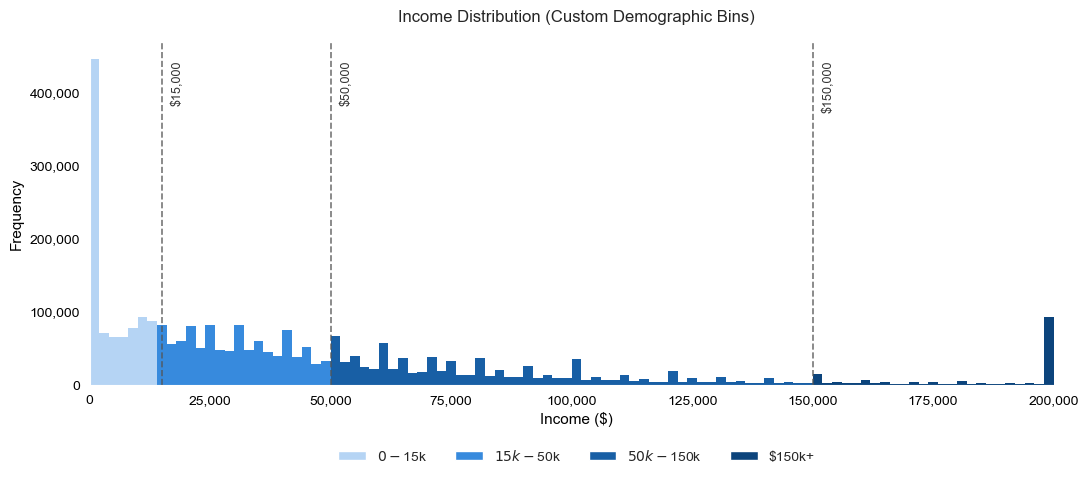

Saved 3a_income_custom_bins.png


In [6]:
CUSTOM_CUTS = [15000, 50000, 150000]
CUSTOM_LABELS = ['$0 - $15k', '$15k - $50k', '$50k - $150k', '$150k+']
CUSTOM_COLORS = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']

capped_income = df['PINCP'].dropna().clip(lower=0, upper=200000)

plot_colored_histogram(
    data=capped_income,
    cut_points=CUSTOM_CUTS,
    labels=CUSTOM_LABELS,
    colors=CUSTOM_COLORS,
    title='Income Distribution (Custom Demographic Bins)',
    filename='data-analysis/3a_income_custom_bins.png'
)

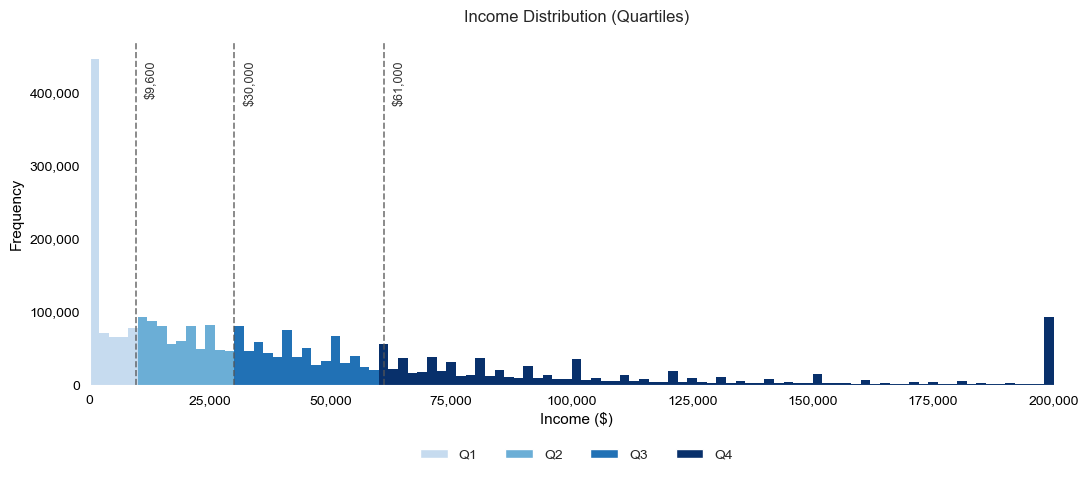

Saved 3b_income_quartiles.png


In [7]:
q_cuts = df['PINCP'].quantile([0.25, 0.5, 0.75]).values
Q_LABELS = ['Q1', 'Q2', 'Q3', 'Q4']
Q_COLORS = ['#C6DBEF', '#6BAED6', '#2171B5', '#08306B']

plot_colored_histogram(
    data=capped_income,
    cut_points=q_cuts,
    labels=Q_LABELS,
    colors=Q_COLORS,
    title='Income Distribution (Quartiles)',
    filename='data-analysis/3b_income_quartiles.png'
)

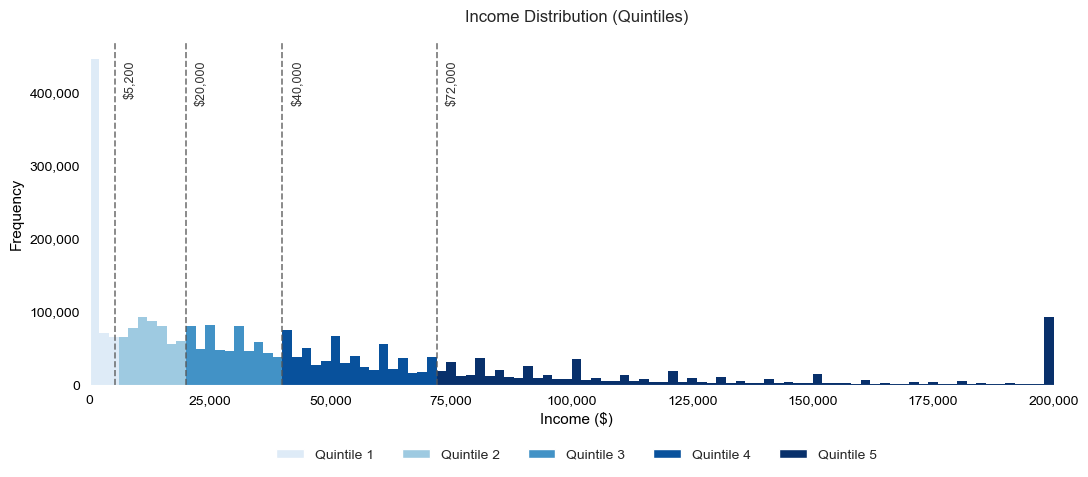

Saved 3c_income_quintiles.png


In [8]:
quint_cuts = df['PINCP'].quantile([0.2, 0.4, 0.6, 0.8]).values
QUINT_LABELS = ['Quintile 1', 'Quintile 2', 'Quintile 3', 'Quintile 4', 'Quintile 5']
QUINT_COLORS = ['#DEEBF7', '#9ECAE1', '#4292C6', '#08519C', '#08306B']

plot_colored_histogram(
    data=capped_income,
    cut_points=quint_cuts,
    labels=QUINT_LABELS,
    colors=QUINT_COLORS,
    title='Income Distribution (Quintiles)',
    filename='data-analysis/3c_income_quintiles.png'
)

=== Educational Attainment Distribution ===
  No HS Diploma: 821,969 (25.09%)
  HS Diploma/GED: 746,974 (22.80%)
  Some College/Assoc.: 794,132 (24.24%)
  Bachelor's+: 913,140 (27.87%)


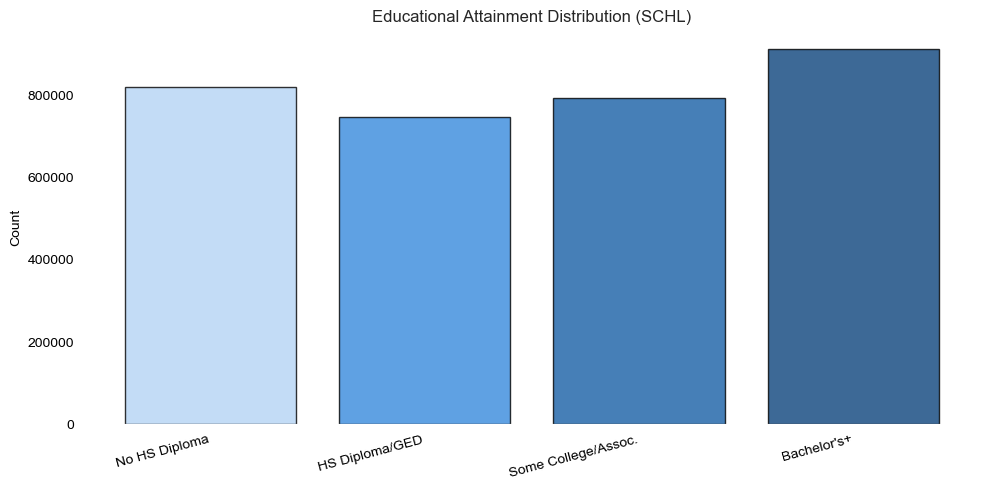

Saved schl_distribution.png


In [20]:
SCHL_BINS = [0, 16, 18, 21, 25]
SCHL_LABELS = ['No HS Diploma', 'HS Diploma/GED', 'Some College/Assoc.', "Bachelor's+"]
SCHL_COLORS = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']

df['SCHL_BIN'] = pd.cut(df['SCHL'].dropna(), bins=SCHL_BINS, labels=SCHL_LABELS, right=False)

schl_counts = df['SCHL_BIN'].value_counts().sort_index()
print("=== Educational Attainment Distribution ===")
total = schl_counts.sum()
for label, count in schl_counts.items():
    print(f"  {label}: {count:,} ({count/total*100:.2f}%)")

# Bar chart
plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
bars = ax.bar(schl_counts.index, schl_counts.values,
              color=SCHL_COLORS, edgecolor='black', alpha=0.8)
ax.set_ylabel('Count', color='black')
ax.set_title('Educational Attainment Distribution (SCHL)')
ax.tick_params(colors='black')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('schl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved schl_distribution.png")

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

age_bins = [0, 25, 45, 65, 98]
age_labels = ['Youth (0-24)', 'Young Adult (25-44)', 'Adult (45-64)', 'Senior (65+)']
df['AGE_BIN'] = pd.cut(df['AGEP'], bins=age_bins, labels=age_labels, right=False)

inc_bins = [-np.inf, 15000, 50000, 150000, np.inf]
inc_labels = ['Low (<15k)', 'Working (15-50k)', 'Middle (50-150k)', 'High (150k+)']
df['INC_BIN'] = pd.cut(df['PINCP'].fillna(0), bins=inc_bins, labels=inc_labels)

df['SEX_LABEL'] = df['SEX'].map({1: 'Male', 2: 'Female'})

if 'SCHL_BIN' not in df.columns:
    schl_bins = [0, 16, 18, 21, 25]
    schl_labels = ['No HS Diploma', 'HS Diploma/GED', 'Some College/Assoc.', "Bachelor's+"]
    df['SCHL_BIN'] = pd.cut(df['SCHL'].dropna(), bins=schl_bins, labels=schl_labels, right=False)

race_col = 'RAC1P' if 'RAC1P' in df.columns else 'RACE'

df['RACE_BINARY'] = df[race_col].apply(lambda x: 'White' if x == 1 else 'Non-White')

def merge_race_6(r):
    if r == 1: return 'White'
    elif r == 2: return 'Black'
    elif r == 6: return 'Asian'
    elif r in [3, 4, 5, 7]: return 'Native'
    elif r == 8: return 'Other'
    elif r == 9: return 'Multi'
    else: return 'Other'

df['RACE_6'] = df[race_col].apply(merge_race_6)

In [36]:
def spatial_segregation_analysis(df, group_col, lat_col='Latitude', lon_col='Longitude',
                                 n_lat_bins=20, n_lon_bins=30):
    """
    Compute spatial unevenness of group distributions.
    Returns:
      - dissimilarity_index (for binary) or mean pairwise DI
      - variance of group proportions across spatial bins
      - a DataFrame of per-bin group proportions for plotting
    """
    df_valid = df[[lat_col, lon_col, group_col]].dropna()

    df_valid = df_valid.copy()
    df_valid['lat_bin'] = pd.cut(df_valid[lat_col], bins=n_lat_bins, labels=False)
    df_valid['lon_bin'] = pd.cut(df_valid[lon_col], bins=n_lon_bins, labels=False)
    df_valid['grid_cell'] = df_valid['lat_bin'].astype(str) + '_' + df_valid['lon_bin'].astype(str)

    cell_counts = df_valid.groupby(['grid_cell', group_col]).size().unstack(fill_value=0)
    cell_totals = cell_counts.sum(axis=1)
    cell_props = cell_counts.div(cell_totals, axis=0)

    mask = cell_totals >= 50
    cell_props_filtered = cell_props[mask]
    cell_counts_filtered = cell_counts[mask]
    cell_totals_filtered = cell_totals[mask]

    global_props = df_valid[group_col].value_counts(normalize=True)

    prop_variance = cell_props_filtered.var()

    groups = cell_counts_filtered.columns.tolist()
    T = cell_totals_filtered.sum()

    di_values = {}
    for g in groups:
        T_g = cell_counts_filtered[g].sum()
        if T_g == 0 or T_g == T:
            di_values[g] = 0.0
            continue
        term = np.abs(cell_counts_filtered[g] / T_g -
                      (cell_totals_filtered - cell_counts_filtered[g]) / (T - T_g))
        di_values[g] = 0.5 * term.sum()

    global_p = global_props.reindex(groups).values
    kl_divs = []
    for _, row in cell_props_filtered.iterrows():
        q = row.reindex(groups).values
        q_safe = np.clip(q, 1e-10, 1.0)
        p_safe = np.clip(global_p, 1e-10, 1.0)
        kl_divs.append(entropy(q_safe, p_safe))
    mean_kl = np.mean(kl_divs)

    return {
        'prop_variance': prop_variance.to_dict(),
        'dissimilarity_index': di_values,
        'mean_kl_divergence': mean_kl,
        'n_cells_used': mask.sum(),
        'global_proportions': global_props.to_dict(),
        'cell_props': cell_props_filtered
    }

features_to_analyze = {
    'Race (Binary)': 'RACE_BINARY',
    'Race (6-bin)': 'RACE_6',
    'Race (9 raw)': race_col,
    'Age': 'AGE_BIN',
    'Income': 'INC_BIN',
    'Sex': 'SEX_LABEL'
}

segregation_results = {}
for name, col in features_to_analyze.items():
    try:
        result = spatial_segregation_analysis(df, col)
        segregation_results[name] = result
        print(f"\n{'='*60}")
        print(f"Feature: {name} (column: {col})")
        print(f"  Grid cells used: {result['n_cells_used']}")
        print(f"Mean Dissimilarity: {np.mean(list(result['dissimilarity_index'].values()))}")
        print(f"  Mean KL divergence from global: {result['mean_kl_divergence']:.4f}")
        print(f"  Dissimilarity Index per group:")
        for g, di in result['dissimilarity_index'].items():
            print(f"    {g}: {di:.4f}")
        print(f"  Proportion variance across cells:")
        for g, v in result['prop_variance'].items():
            print(f"    {g}: {v:.6f}")
    except Exception as e:
        print(f"Error for {name}: {e}")


Feature: Race (Binary) (column: RACE_BINARY)
  Grid cells used: 140
Mean Dissimilarity: 0.28795731158887705
  Mean KL divergence from global: 0.0734
  Dissimilarity Index per group:
    Non-White: 0.2880
    White: 0.2880
  Proportion variance across cells:
    Non-White: 0.029115
    White: 0.029115

Feature: Race (6-bin) (column: RACE_6)
  Grid cells used: 140
Mean Dissimilarity: 0.3430229372031843
  Mean KL divergence from global: 0.1889
  Dissimilarity Index per group:
    Asian: 0.3941
    Black: 0.3352
    Multi/PI: 0.2466
    Native/AI: 0.4322
    Other: 0.3621
    White: 0.2880
  Proportion variance across cells:
    Asian: 0.003246
    Black: 0.004939
    Multi/PI: 0.010000
    Native/AI: 0.006600
    Other: 0.001867
    White: 0.029115

Feature: Race (9 raw) (column: RAC1P)
  Grid cells used: 140
Mean Dissimilarity: 0.4153789084401384
  Mean KL divergence from global: 0.2155
  Dissimilarity Index per group:
    1: 0.2880
    2: 0.3352
    3: 0.4479
    4: 0.8739
    5: 0.267

C:\Users\Peete\AppData\Local\Temp\ipykernel_11808\972135727.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df_valid.groupby(['grid_cell', group_col]).size().unstack(fill_value=0)



Feature: Age (column: AGE_BIN)
  Grid cells used: 140
Mean Dissimilarity: 0.042311353312085034
  Mean KL divergence from global: 0.0086
  Dissimilarity Index per group:
    Youth (0-24): 0.0377
    Young Adult (25-44): 0.0468
    Adult (45-64): 0.0224
    Senior (65+): 0.0624
  Proportion variance across cells:
    Youth (0-24): 0.001271
    Young Adult (25-44): 0.000615
    Adult (45-64): 0.000316
    Senior (65+): 0.001825


C:\Users\Peete\AppData\Local\Temp\ipykernel_11808\972135727.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df_valid.groupby(['grid_cell', group_col]).size().unstack(fill_value=0)



Feature: Income (column: INC_BIN)
  Grid cells used: 140
Mean Dissimilarity: 0.09462533403267429
  Mean KL divergence from global: 0.0136
  Dissimilarity Index per group:
    Low (<15k): 0.0514
    Working (15-50k): 0.0674
    Middle (50-150k): 0.0714
    High (150k+): 0.1884
  Proportion variance across cells:
    Low (<15k): 0.002110
    Working (15-50k): 0.001068
    Middle (50-150k): 0.001191
    High (150k+): 0.000436

Feature: Sex (column: SEX_LABEL)
  Grid cells used: 140
Mean Dissimilarity: 0.012893296317195973
  Mean KL divergence from global: 0.0004
  Dissimilarity Index per group:
    Female: 0.0129
    Male: 0.0129
  Proportion variance across cells:
    Female: 0.000166
    Male: 0.000166


C:\Users\Peete\AppData\Local\Temp\ipykernel_11808\1467658091.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


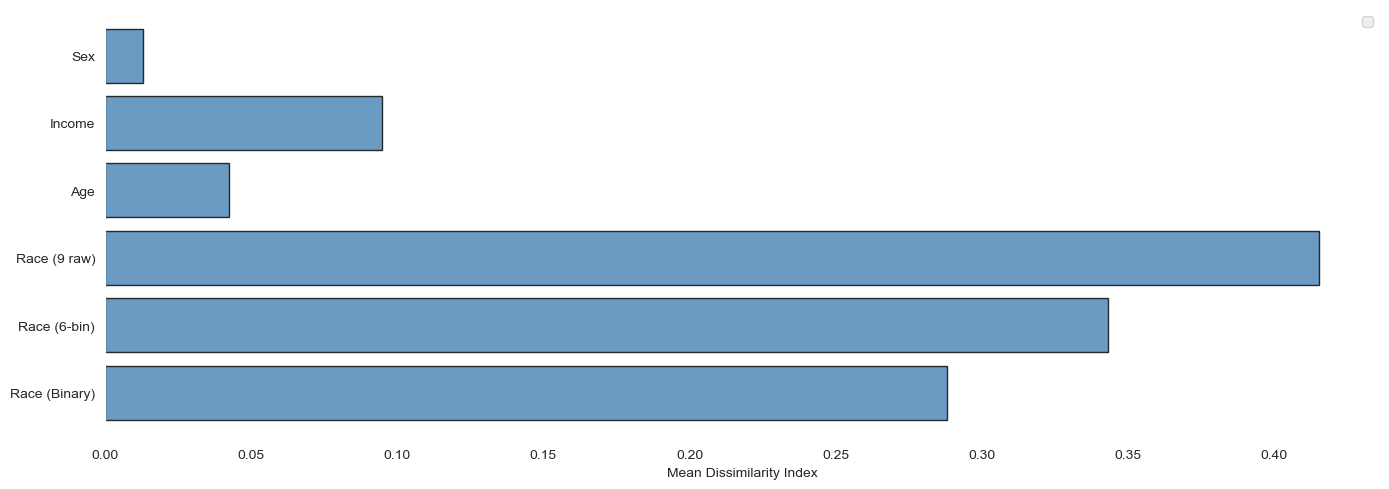

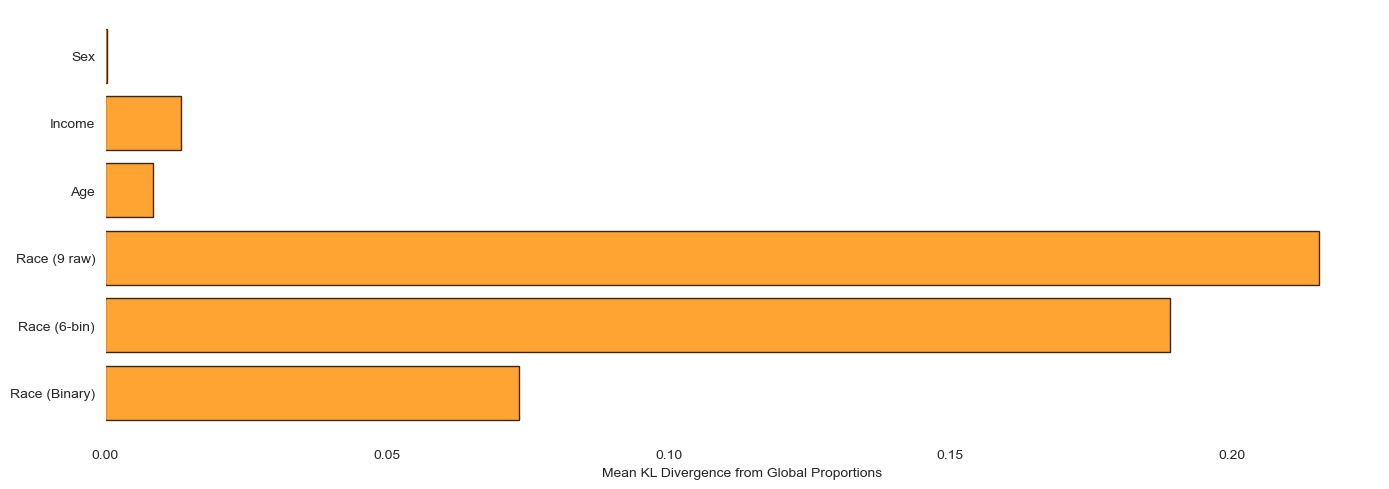


Interpretation: Features with high DI/KL will produce meaningful PoF experiments.
Features near zero (likely Sex) will yield PoF ≈ 1 — confirming your thesis claim.


In [37]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5), facecolor='white')

feature_names = []
mean_dis = []
mean_kls = []
for name, res in segregation_results.items():
    feature_names.append(name)
    mean_dis.append(np.mean(list(res['dissimilarity_index'].values())))
    mean_kls.append(res['mean_kl_divergence'])

ax = axes
ax.set_facecolor('white')
bars = ax.barh(feature_names, mean_dis, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Mean Dissimilarity Index')
ax.legend()

plt.tight_layout()
plt.savefig('geographic_segregation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 1, figsize=(14, 5), facecolor='white')

ax = axes
ax.set_facecolor('white')
ax.barh(feature_names, mean_kls, color='darkorange', edgecolor='black', alpha=0.8)
ax.set_xlabel('Mean KL Divergence from Global Proportions')

plt.tight_layout()
plt.savefig('geographic_segregation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nInterpretation: Features with high DI/KL will produce meaningful PoF experiments.")
print("Features near zero (likely Sex) will yield PoF ≈ 1 — confirming your thesis claim.")

In [24]:
def feasibility_check(df, group_col, n_values, k_values, alpha_values):
    """Check if fairness constraints are feasible for given parameters."""
    group_counts = df[group_col].value_counts()
    total = len(df)
    group_props = group_counts / total

    results = []
    for n in n_values:
        for k in k_values:
            for alpha in alpha_values:
                cluster_size = n / k
                feasible = True
                bottleneck_group = None
                min_ratio = float('inf')

                for group, prop in group_props.items():
                    beta = max(0, prop - alpha)
                    min_per_cluster = np.ceil(beta * cluster_size)
                    expected_total = prop * n
                    needed = k * min_per_cluster
                    ratio = expected_total / needed if needed > 0 else float('inf')

                    if ratio < min_ratio:
                        min_ratio = ratio
                        bottleneck_group = group

                    if expected_total < needed:
                        feasible = False

                results.append({
                    'group_col': group_col,
                    'n_groups': len(group_counts),
                    'n': n,
                    'k': k,
                    'alpha': alpha,
                    'feasible': feasible,
                    'bottleneck_group': bottleneck_group,
                    'bottleneck_ratio': min_ratio,
                    'smallest_group_pct': group_props.min() * 100,
                    'smallest_group': group_props.idxmin(),
                })

    return pd.DataFrame(results)

n_vals = [10000]
k_vals = [3, 5, 10, 20, 50]
alpha_vals = [0.01, 0.02, 0.05, 0.1, 0.2]

# Check for each color configuration
color_configs = {
    'Sex (L=2)': 'SEX_LABEL',
    'Age (L=4)': 'AGE_BIN',
    'Income (L=4)': 'INC_BIN',
    'Race 6-bin (L=6)': 'RACE_6',
    'Race 9-raw (L=9)': race_col,
    'Race binary (L=2)': 'RACE_BINARY',
}

all_feasibility = []
for name, col in color_configs.items():
    res = feasibility_check(df, col, n_vals, k_vals, alpha_vals)
    res['config_name'] = name
    all_feasibility.append(res)

feasibility_df = pd.concat(all_feasibility, ignore_index=True)

infeasible = feasibility_df[~feasibility_df['feasible']]
print("=== INFEASIBLE CONFIGURATIONS ===")
if len(infeasible) == 0:
    print("All configurations are feasible!")
else:
    print(infeasible[['config_name', 'n', 'k', 'alpha', 'bottleneck_group',
                       'smallest_group_pct', 'bottleneck_ratio']].to_string(index=False))

borderline = feasibility_df[(feasibility_df['feasible']) & (feasibility_df['bottleneck_ratio'] < 2.0)]
print("\n=== BORDERLINE CONFIGURATIONS (feasible but tight, ratio < 2.0) ===")
if len(borderline) > 0:
    print(borderline[['config_name', 'n', 'k', 'alpha', 'bottleneck_group',
                       'smallest_group_pct', 'bottleneck_ratio']].to_string(index=False))


=== INFEASIBLE CONFIGURATIONS ===
All configurations are feasible!

=== BORDERLINE CONFIGURATIONS (feasible but tight, ratio < 2.0) ===
      config_name     n  k  alpha bottleneck_group  smallest_group_pct  bottleneck_ratio
        Sex (L=2) 10000  3   0.01           Female           49.101483          1.019602
        Sex (L=2) 10000  3   0.02           Female           49.101483          1.040869
        Sex (L=2) 10000  3   0.05           Female           49.101483          1.108900
        Sex (L=2) 10000  3   0.10           Female           49.101483          1.243854
        Sex (L=2) 10000  3   0.20           Female           49.101483          1.647201
        Sex (L=2) 10000  5   0.01             Male           49.101483          1.019761
        Sex (L=2) 10000  5   0.02           Female           49.101483          1.040869
        Sex (L=2) 10000  5   0.05           Female           49.101483          1.108900
        Sex (L=2) 10000  5   0.10           Female           49